In [2]:
import all_samplers
import matplotlib.pyplot as plt
import numpy as np
import importlib as imp

In [64]:
imp.reload(all_samplers)

<module 'all_samplers' from 'c:\\Users\\benga\\OneDrive\\Desktop\\CAM\\RSCAM\\Group Report\\rscam-mcmc-nonsmooth-sampling-main\\rscam-mcmc-nonsmooth-sampling-main\\all_samplers.py'>

In [70]:
config = all_samplers.SamplerConfig()

Sampling...
Done Gibbs sampling
Done MYULA sampling
Done Hadamard sampling


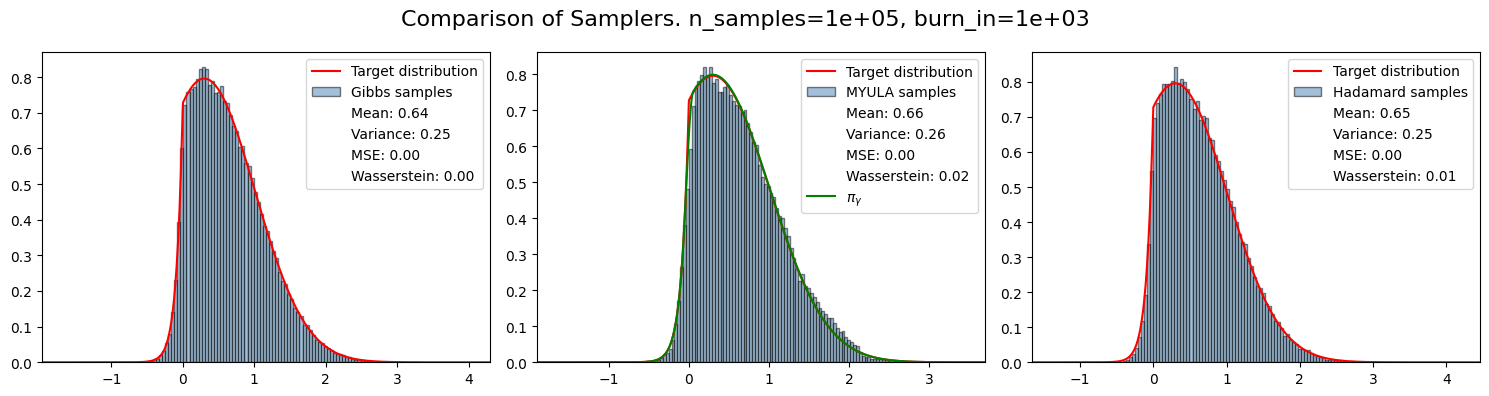

In [ ]:
all_samplers.main_all()

In [73]:
import arviz as az

c:\Users\benga\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [74]:
Ks = np.linspace(20, 100, 10)
mses = []
seconds = []
wass = []
samples = []
esss = []
for K in Ks:
    sample = all_samplers.myula_sampler(K, config)
    mses.append(config.mse_first_moment(sample))
    seconds.append(config.mse_second_moment(sample))
    wass.append(config.wassterstein(sample))
    samples.append(sample)
    esss.append(az.ess(sample))

C:\Users\benga\AppData\Local\Temp\ipykernel_20708\1944834544.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(Ks))
C:\Users\benga\AppData\Local\Temp\ipykernel_20708\1944834544.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(Ks))
C:\Users\benga\AppData\Local\Temp\ipykernel_20708\1944834544.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(Ks))
C:\Users\benga\AppData\Local\Temp\ipykernel_20708\1944834544.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(Ks))


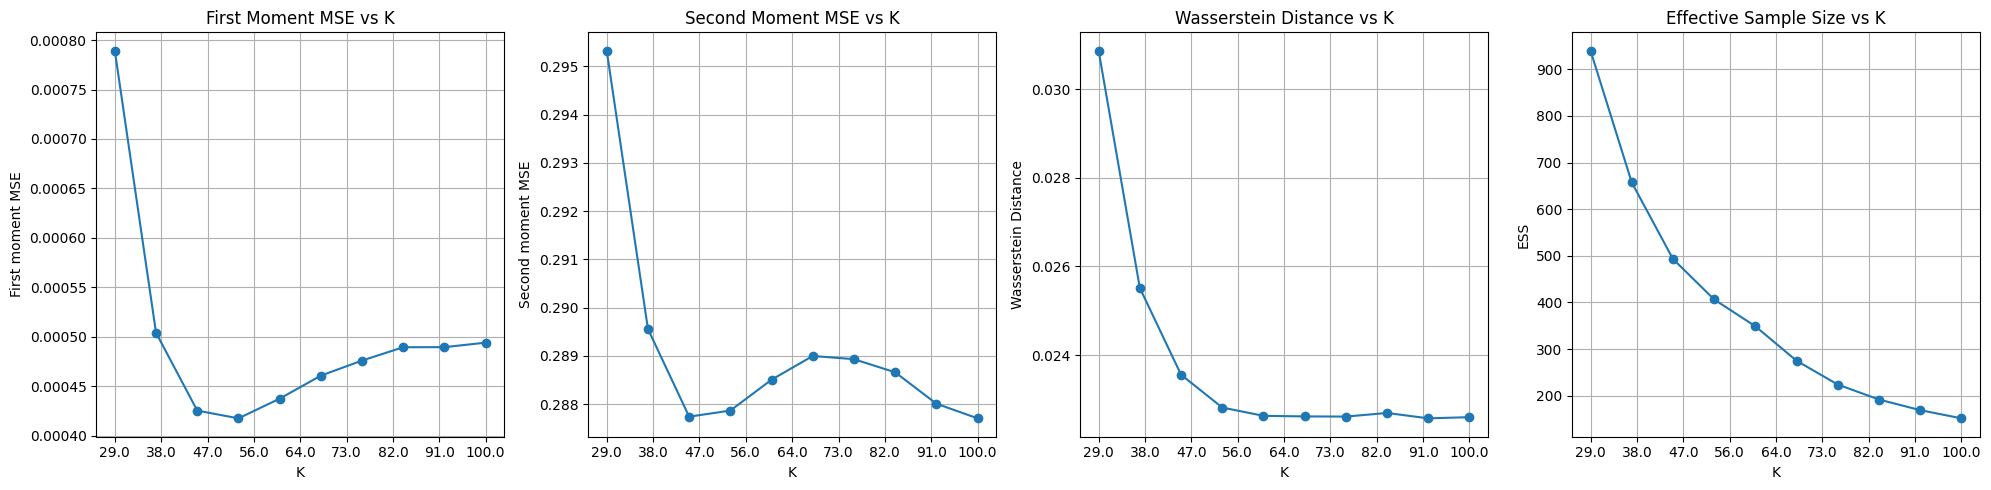

In [77]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].plot(Ks, mses, marker='o')
axs[0].set_title('First Moment MSE vs K')
axs[0].set_ylabel('First moment MSE')

axs[1].plot(Ks, seconds, marker='o')
axs[1].set_title('Second Moment MSE vs K')
axs[1].set_ylabel('Second moment MSE')
axs[2].plot(Ks, wass, marker='o')
axs[2].set_title('Wasserstein Distance vs K')
axs[2].set_ylabel('Wasserstein Distance')
axs[3].plot(Ks, esss, marker='o')
axs[3].set_title('Effective Sample Size vs K')
axs[3].set_ylabel('ESS')

for ax in axs:
    ax.set_xlabel('K')
    ax.set_xticklabels(np.round(Ks))
    ax.grid()
plt.tight_layout()
plt.show()

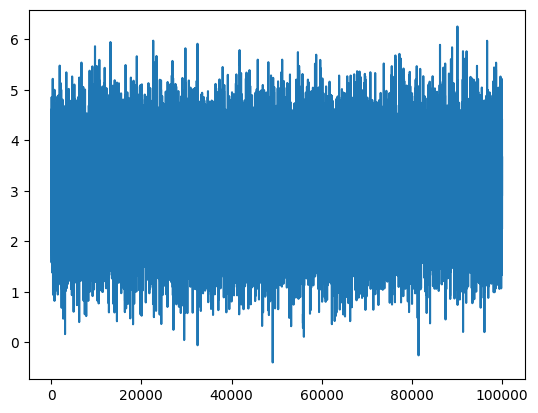

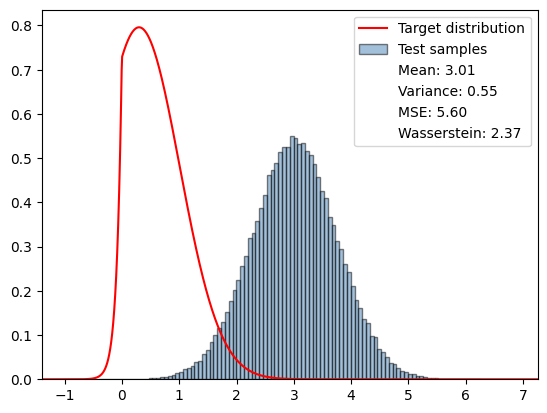

In [41]:
sample = all_samplers.myula_sampler(0.00000001, config)
plt.plot(sample)
plt.show()
config.plot_sample(sample, 'Test', ax=None)

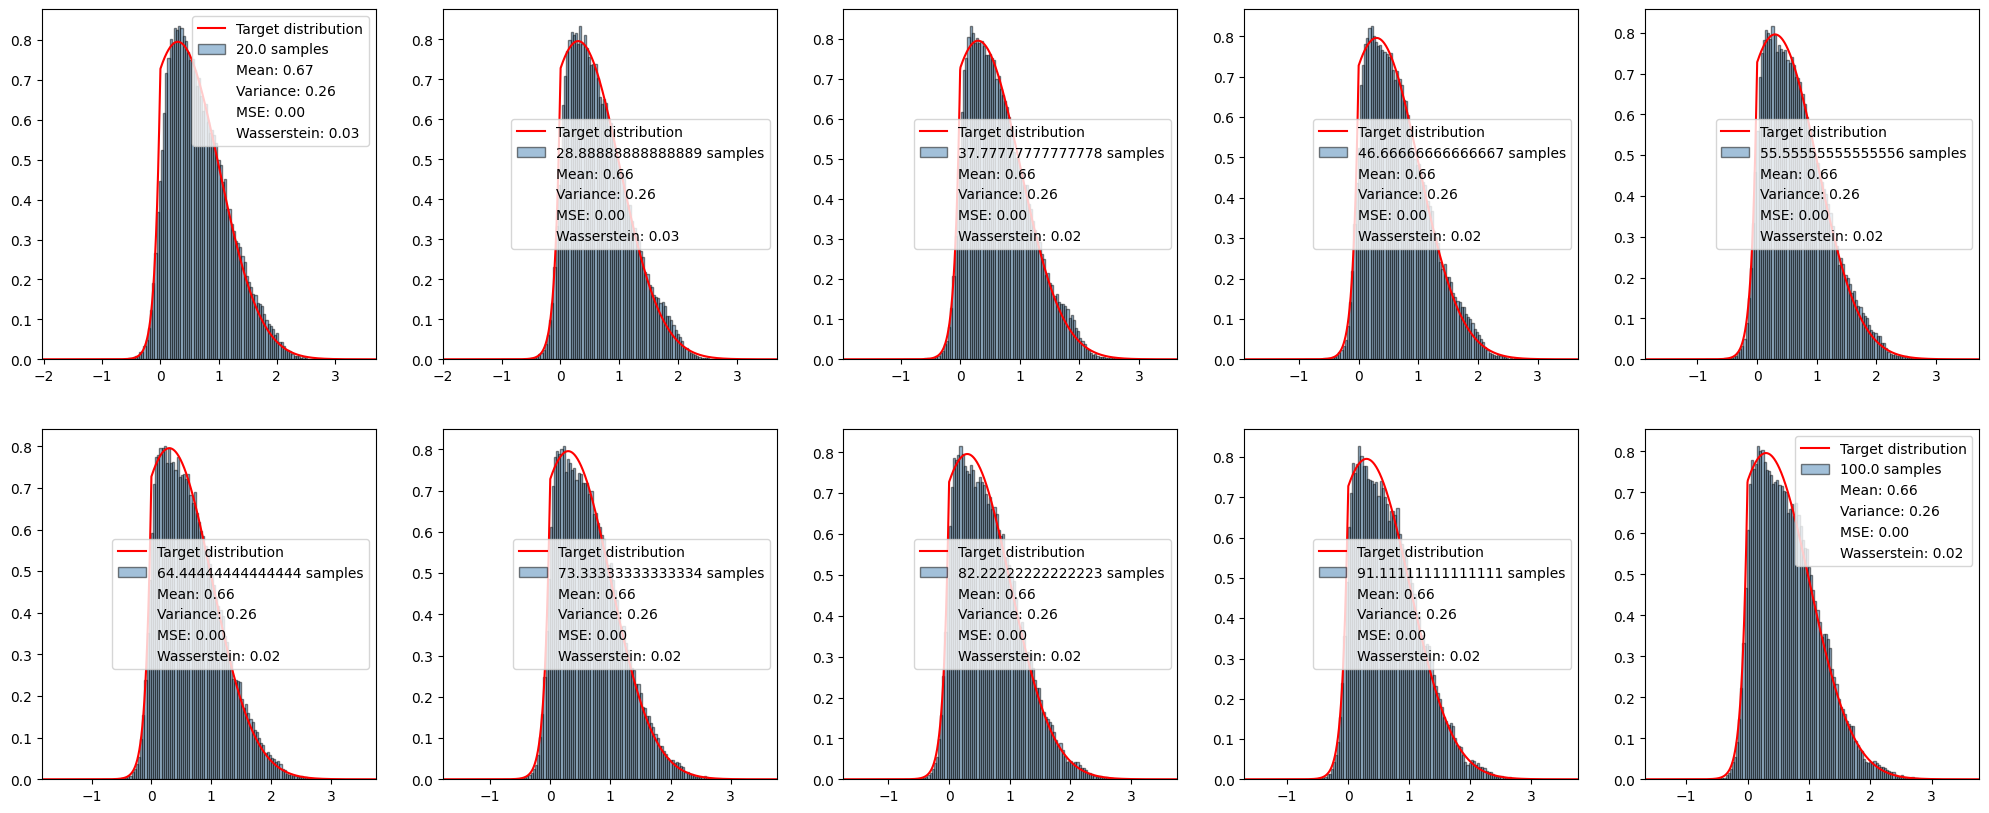

In [34]:
fig, axs = plt.subplots(2, 5, figsize=(25, 10))
for K, sample, ax in zip(Ks, samples, axs.flatten()):
    config.plot_sample(sample, K, ax=ax)

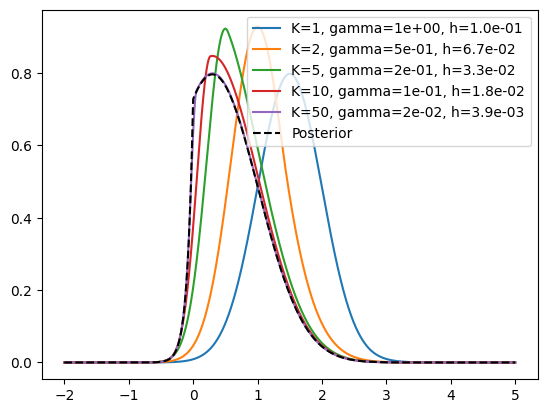

In [72]:
xx = np.linspace(-2, 5, 10000)

L = config.a**2
for K in [1, 2, 5, 10, 50]:
    gamma = 1.0 / (K*L)
    h = gamma / (5*(gamma*L + 1))
    plt.plot(xx, all_samplers.make_pi_gamma(gamma, config)(xx), label=f'K={K:.0f}, gamma={gamma:.0e}, h={h:.1e}')
    
plt.plot(xx, config.posterior(xx), linestyle='--', color='black', label='Posterior')
plt.legend()
plt.show()